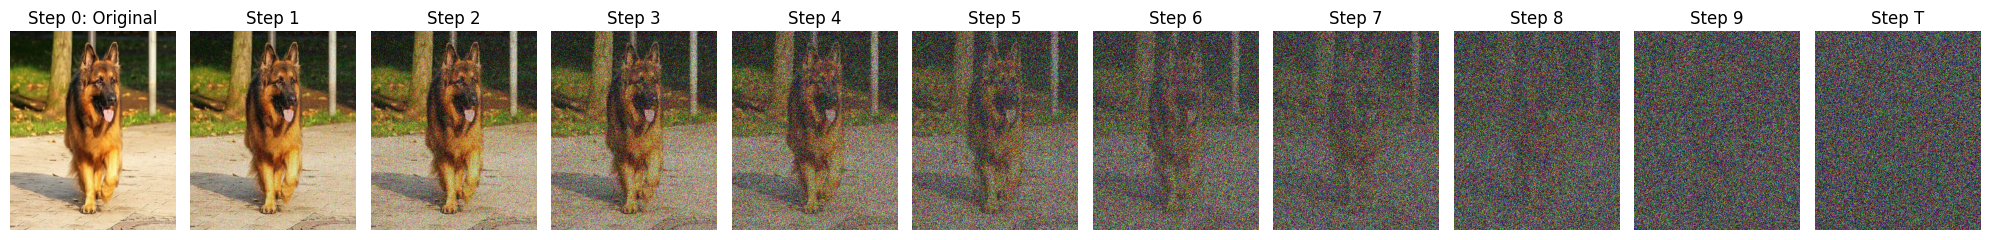

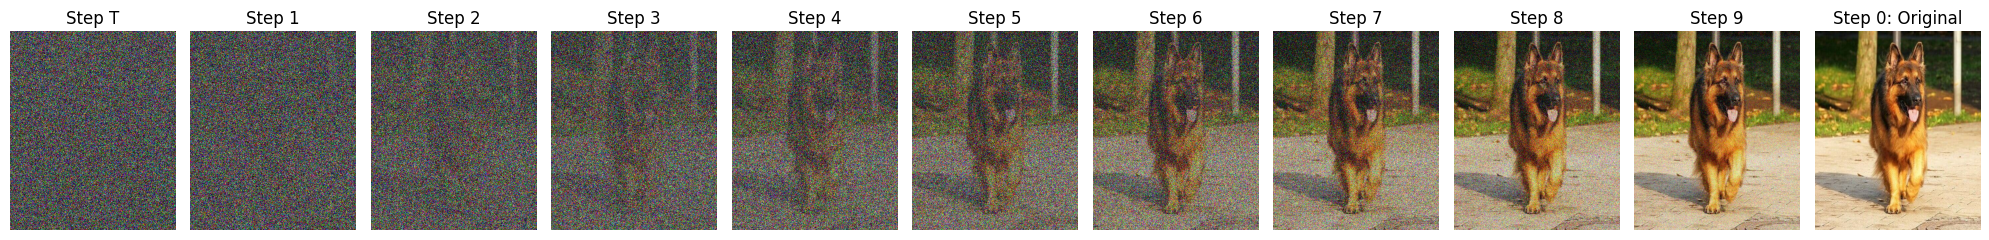

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Function to add Gaussian noise incrementally across timesteps
def add_gaussian_noise(image, step, total_steps):
    # Gradually blend the image with pure Gaussian noise
    noise = np.random.normal(0, 1, image.shape)  # Generate pure Gaussian noise
    alpha = step / total_steps  # Compute alpha blending factor
    noisy_image = (1 - alpha) * image + alpha * noise  # Linearly blend image with noise
    return np.clip(noisy_image, 0, 1)  # Ensure pixel values are between 0 and 1

# Load and preprocess the image
image_path = "imgs/dog3.jpg"  # Replace with your image file path
image = Image.open(image_path).convert("RGB")
image = image.resize((500, 600))  # Resize for consistency
image_array = np.array(image) / 255.0  # Normalize to [0, 1]
# print(image)

# Diffusion process parameters
num_steps = 10  # Total number of steps

# Initialize plot
fig, axes = plt.subplots(1, num_steps + 1, figsize=(20, 5))

# Plot the original image
axes[0].imshow(image_array)
axes[0].set_title("Step 0: Original")
axes[0].axis("off")

# Perform the diffusion process
for step in range(1, num_steps + 1):
    noisy_image = add_gaussian_noise(image_array, step, num_steps)
    axes[step].imshow(noisy_image)
    if step == num_steps:
        axes[step].set_title(f"Step {'T'}")
    else:
        axes[step].set_title(f"Step {step}")
    axes[step].axis("off")

# Display the results
plt.tight_layout()
plt.show()

# Initialize second plot
fig, axes = plt.subplots(1, num_steps + 1, figsize=(20, 5))

# Plot the original image
axes[num_steps].imshow(image_array)
axes[num_steps].set_title("Step 0: Original")
axes[num_steps].axis("off")

# Perform the diffusion process
for step in range(num_steps, 0, -1):
    noisy_image = add_gaussian_noise(image_array, step, num_steps)
    axes[num_steps - step].imshow(noisy_image)
    if step == num_steps:
        axes[num_steps - step].set_title(f"Step {'T'}")
    else:
        axes[num_steps - step].set_title(f"Step {num_steps - step}")
    axes[num_steps - step].axis("off")

# Display the results
plt.tight_layout()
plt.show()

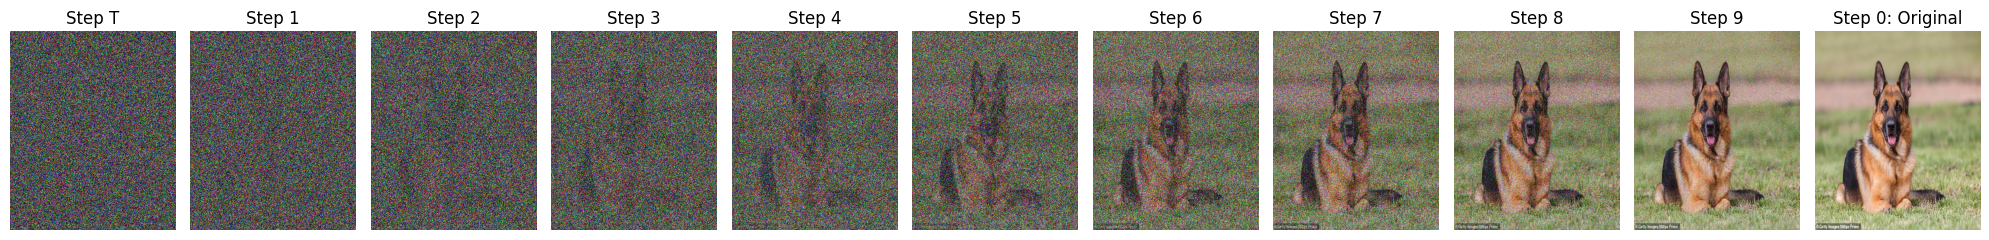

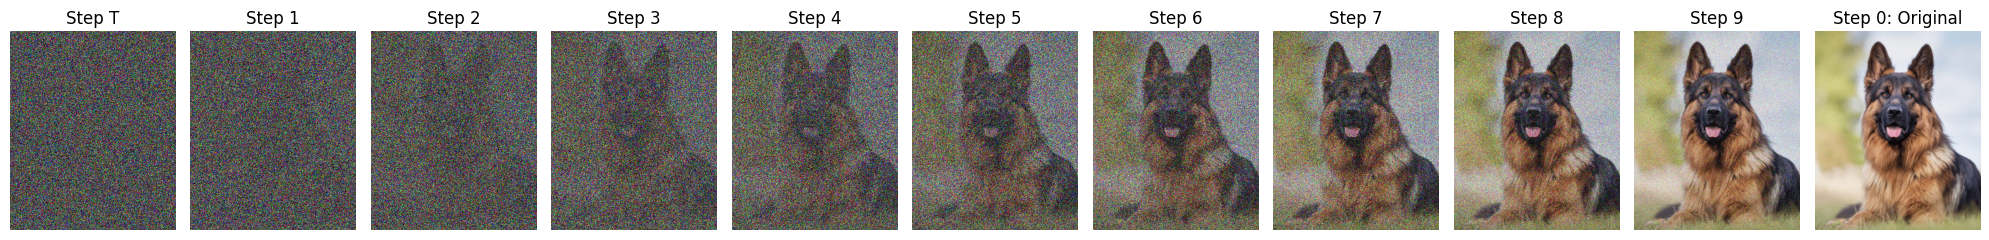

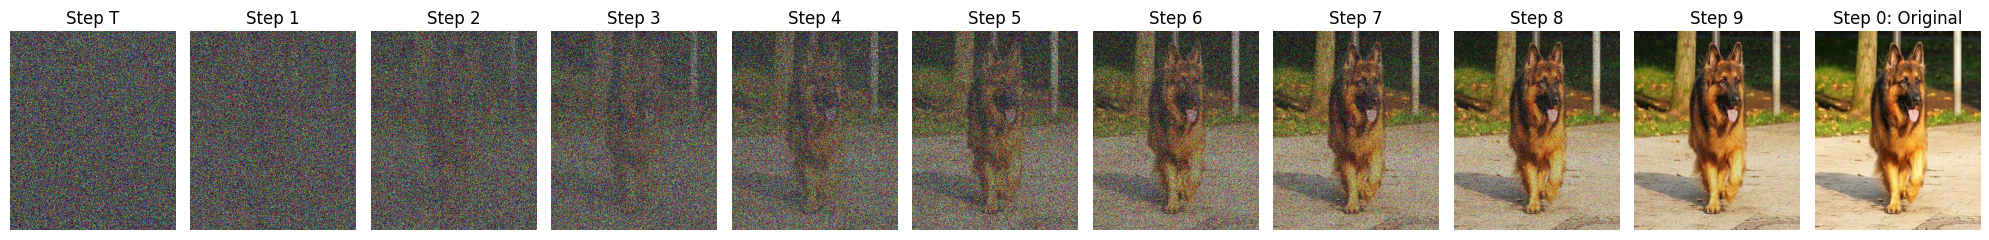

In [3]:
for i in range(1, 4):
    # Load and preprocess the image
    image_path = "imgs/dog" + str(i) + ".jpg"  # Replace with your image file path
    image = Image.open(image_path).convert("RGB")
    image = image.resize((500, 600))  # Resize for consistency
    image_array = np.array(image) / 255.0  # Normalize to [0, 1]
    
    
    # Initialize second plot
    fig, axes = plt.subplots(1, num_steps + 1, figsize=(20, 5))
    
    # Plot the original image
    axes[num_steps].imshow(image_array)
    axes[num_steps].set_title("Step 0: Original")
    axes[num_steps].axis("off")
    
    # Perform the diffusion process
    for step in range(num_steps, 0, -1):
        noisy_image = add_gaussian_noise(image_array, step, num_steps)
        axes[num_steps - step].imshow(noisy_image)
        if step == num_steps:
            axes[num_steps - step].set_title(f"Step {'T'}")
        else:
            axes[num_steps - step].set_title(f"Step {num_steps - step}")
        axes[num_steps - step].axis("off")
    
    # Display the results
    plt.tight_layout()
    plt.show()
    


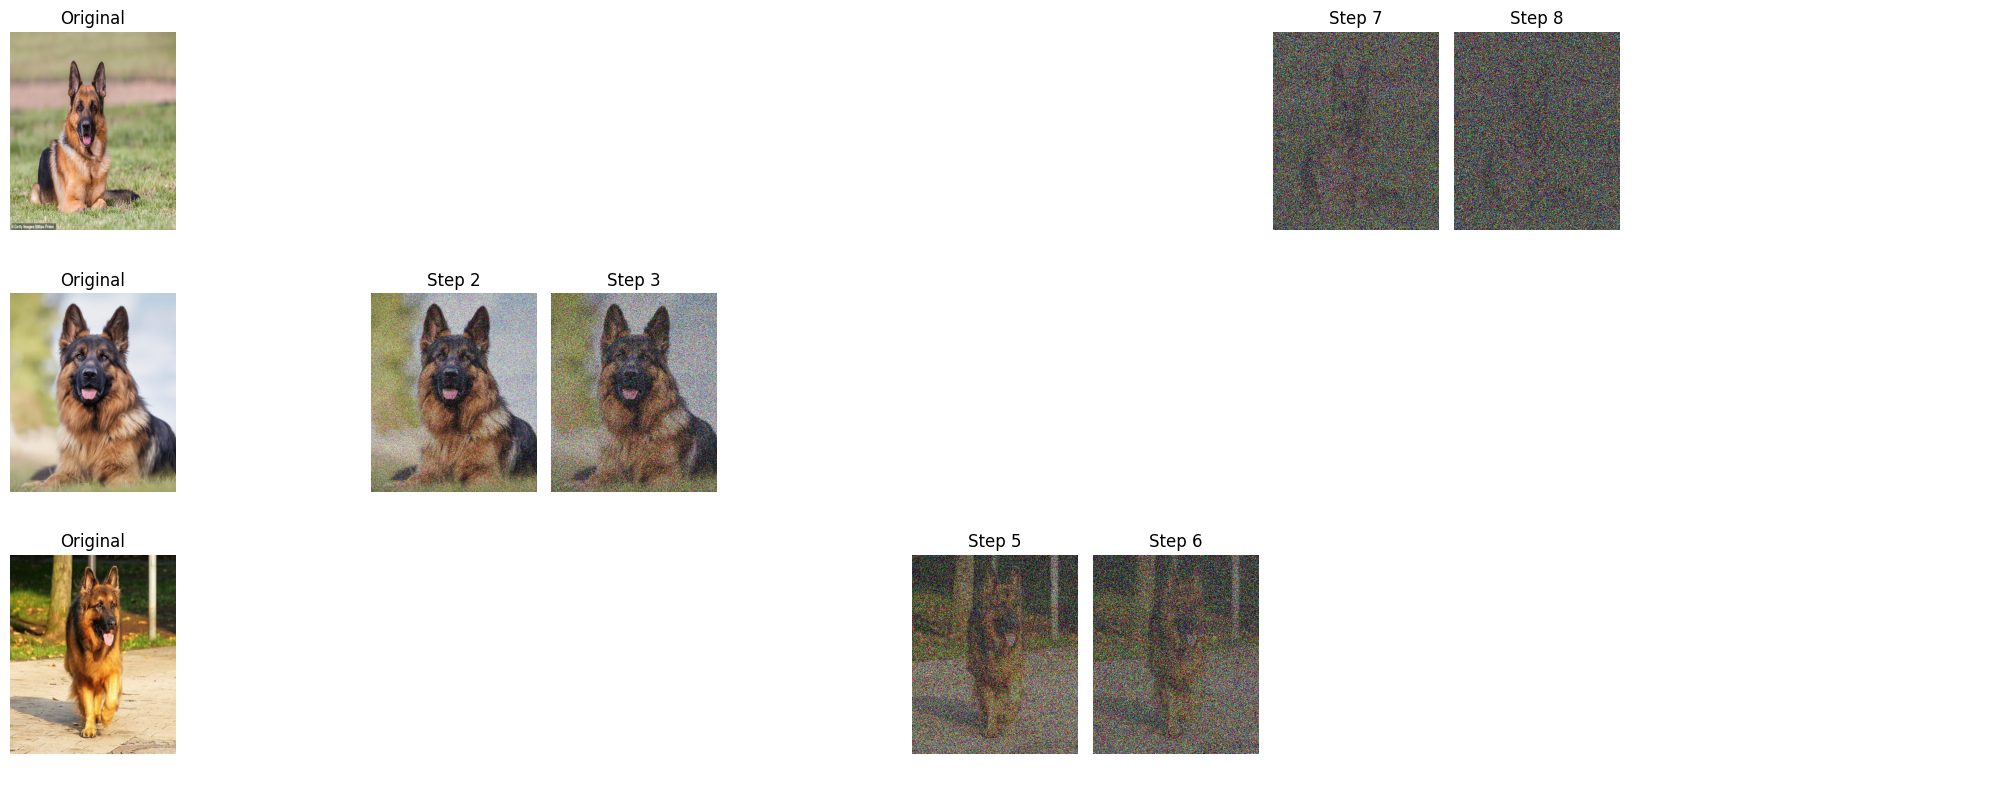

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Define which timesteps to show for each dog
dog_timesteps = {
    1: (7, 8),  # Dog 1: steps 7 & 8
    2: (2, 3),  # Dog 2: steps 2 & 3
    3: (5, 6)   # Dog 3: steps 5 & 6
}

num_steps = 10  # total steps in your diffusion process

fig, axes = plt.subplots(3, num_steps + 1, figsize=(20, 8))

for i in range(1, 4):
    # Load and preprocess the image
    image_path = f"imgs/dog{i}.jpg"
    image = Image.open(image_path).convert("RGB")
    image = image.resize((500, 600))
    image_array = np.array(image) / 255.0

    # Get timesteps for this dog
    t1, t2 = dog_timesteps[i]
    row = i - 1

    # Original goes in the **first column**
    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    # Place timesteps starting from col=1 onward
    for step in (t1, t2):
        noisy_image = add_gaussian_noise(image_array, step, num_steps)
        col = step  # shift by 1 because col=0 is Original
        axes[row, col].imshow(noisy_image)
        axes[row, col].set_title(f"Step {step}")
        axes[row, col].axis("off")

    # Hide all unused slots
    for col in range(1, num_steps + 1):
        if col not in (t1, t2):
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()